# SimpleRnnlm

这个 notebook 用来基于 `my-torch-lib` 手动实现并训练一个最小版 `SimpleRnnlm`。

这一版 notebook 只提供教学结构：
- 每个步骤拆成 `说明` 和 `TODO`
- 每个需要你填写实现的位置都配一个空白代码 cell
- 不提前给出训练代码，方便你自己按步骤完成


## 环境准备：说明

- 这一步的目标是把 notebook 运行环境接到 `deep_learning_implementation`、`my-torch-lib` 和 `my-eval-lib`。
- 后面需要用到 PTB 数据、`SimpleRnnlm`、时间版损失层、batch helper 和困惑度函数。


In [1]:
from pathlib import Path
import sys
import random
import torch
import numpy as np

projects_dir = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(".."))
sys.path.insert(0, str(projects_dir / "my-torch-lib"))
sys.path.insert(0, str(projects_dir / "my-eval-lib"))

from dataset import ptb
from torchlib.models.rnnlm import SimpleRnnlm
from torchlib.layers.softmax_loss import TimeSoftmaxWithLoss
from torchlib.optim.sgd import SGD
from torchlib.utils.rnnlm import create_rnnlm_offsets, create_rnnlm_batch
from eval.metrics import perplexity

## 超参数设置：说明

- 这一格负责定义训练中会反复使用的核心超参数。
- 建议先采用较小规模设置，优先保证 notebook 能快速跑通。


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

batch_size = 10
wordvec_size = 100
hidden_size = 100
time_size = 5
lr = 0.1
max_epoch = 100
corpus_size = 1000
device = 'cpu'

## 读取 PTB 数据：说明

- 这里要从 PTB 训练集取出连续语料。
- 语言模型常见构造方式是：
  - `xs = corpus[:-1]`
  - `ts = corpus[1:]`


## 读取 PTB 数据：TODO

- 调用 `ptb.load_data("train")`
- 按 `corpus_size` 截断语料
- 构造 `xs = corpus[:-1]`
- 构造 `ts = corpus[1:]`
- 计算 `data_size`
- 计算 `vocab_size`
- 打印语料长度和词表大小

自查：`xs` 和 `ts` 各自表示什么？


In [3]:
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus = corpus[:corpus_size]
xs = corpus[:-1]
ts = corpus[1:]
data_size = len(xs)
vocab_size = len(np.unique(corpus))

In [4]:
data_size

999

In [5]:
vocab_size

418

## 张量化：说明

- 这里需要把语料从 NumPy 形式转换成 torch 可直接使用的张量。
- 当前模型仍然使用词 ID 输入，不需要自己手动构造 one-hot。


## 张量化：TODO

- 将 `xs` 转成 `torch.int64`
- 将 `ts` 转成 `torch.int64`
- 如有需要，将张量移动到合适的 `device`

自查：为什么这里的 dtype 应该是整型？


In [6]:
xs = torch.tensor(xs, dtype=torch.int, device=device)
ts = torch.tensor(ts, dtype=torch.int, device=device)

## Offsets 与时间状态：说明

- 这一步负责初始化连续语料 batch 生成所需的状态。
- 你需要把一整条语料切成 `batch_size` 条并行子序列，并维护一个跨 iteration 递增的 `time_idx`。


## Offsets 与时间状态：TODO

- 用 `create_rnnlm_offsets(data_size, batch_size)` 生成 `offsets`
- 初始化 `time_idx = 0`
- 计算 `max_iters`
- 初始化 `ppl_list`

自查：为什么 `time_idx` 不应该在每个 iteration 都重置回 0？


In [7]:
time_idx = 0
max_iters = data_size // (batch_size * time_size)
offsets = create_rnnlm_offsets(data_size, batch_size)

## 初始化模型与损失：说明

- 这里要把模型本体、损失层和优化器准备好。
- 当前设计里，`SimpleRnnlm` 只负责返回 logits，loss 在模型外部单独计算。


## 初始化模型与损失：TODO

- 实例化 `SimpleRnnlm`
- 将模型移动到 `device`
- 实例化 `TimeSoftmaxWithLoss`
- 实例化优化器

自查：为什么这里不把 loss 写进 `SimpleRnnlm.forward()`？


In [8]:
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size, stateful=True)
criterion = TimeSoftmaxWithLoss()
optimizer = SGD(model.parameters(), lr)

## 单步 Batch 演示：说明

- 在进入完整训练循环前，先单独调一次 `create_rnnlm_batch(...)`。
- 这一格的重点是理解：`offsets`、`time_idx` 和尾部回绕逻辑。


## 单步 Batch 演示：TODO

- 调一次 `create_rnnlm_batch(...)`
- 打印 `batch_x`
- 打印 `batch_t`
- 打印 `next_time_idx`

自查：`next_time_idx` 为什么通常等于 `time_idx + time_size`？


In [9]:
batch_x, batch_t, next_time_idx = create_rnnlm_batch(xs, ts, batch_size, time_size, time_idx, offsets)

## 训练循环：说明

- 这是 notebook 的主体部分。
- 推荐的顺序是：取 batch、前向得到 logits、在模型外部算 loss、反向传播、优化器更新、累积损失统计。


## 训练循环：TODO

- 写 epoch 循环
- 写 iter 循环
- 每次调用 `create_rnnlm_batch(...)` 取 `batch_x` 与 `batch_t`
- 必要时将 batch 移动到 `device`
- 调 `model(batch_x)` 得到 `logits`
- 调 `criterion(logits, batch_t)` 得到 `loss`
- 调 `optimizer.zero_grad()`
- 调 `loss.backward()`
- 调 `optimizer.step()`
- 用 `next_time_idx` 更新 `time_idx`
- 累积 `total_loss` 与 `loss_count`

自查：`logits` 的 shape 应该是什么？


In [10]:
def train(batch_x, batch_t):
    logits = model(batch_x)
    loss = criterion(logits, batch_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.truncate_state()

    return loss, model

In [11]:
loss_list = []
for ephoch in range(max_epoch):
    for i in range(max_iters):
        batch_x, batch_t, time_idx = \
            create_rnnlm_batch(xs, ts, batch_size, time_size, time_idx, offsets)
        loss, model = train(batch_x, batch_t)
        loss_list.append(loss.item())

## 困惑度计算：说明

- 这里不要再写模型调用流程。
- 你只需要在训练循环外部基于已经累积好的 loss 统计量计算困惑度。
- 当前项目设计里，`perplexity` 是一个纯指标函数。


## 困惑度计算：TODO

- 先算 `avg_loss = total_loss / loss_count`
- 再调用 `perplexity(avg_loss)`
- 打印每个 epoch 的困惑度
- 把结果记录到 `ppl_list`

自查：为什么 `perplexity` 不负责调模型？


In [12]:
loss_list = np.array(loss_list)

ppl_list = perplexity(loss_list)
perplexity(loss_list.mean())

np.float64(68.37291347699912)

## 绘图：说明

- 训练跑完后，把 `ppl_list` 按 epoch 画出来。
- 重点不是图多漂亮，而是确认训练曲线有没有明显异常。


## 绘图：TODO

- 生成横轴 epoch 序号
- 用 `matplotlib` 画出 `epoch -> perplexity` 曲线
- 补上标题、坐标轴标签和图例

自查：如果曲线不下降，你会优先排查哪里？


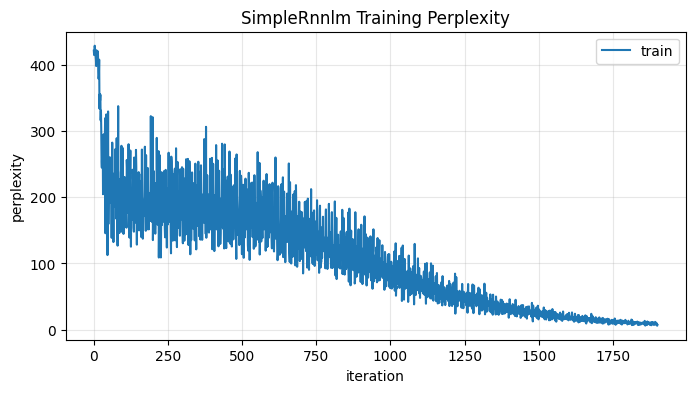

In [13]:
import matplotlib.pyplot as plt

ppl_values = np.atleast_1d(np.asarray(ppl_list, dtype=float))
x = np.arange(1, len(ppl_values) + 1)
x_label = 'epoch' if len(ppl_values) == max_epoch else 'iteration'

plt.figure(figsize=(8, 4))
plt.plot(x, ppl_values, label='train')
plt.title('SimpleRnnlm Training Perplexity')
plt.xlabel(x_label)
plt.ylabel('perplexity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 结果反思：说明

- `SimpleRnnlm` 是教学过渡模型。
- 这一节的重点不是“它够不够强”，而是确认你是否真正理解了这条训练链路。


## 结果反思：TODO

- 总结连续语料 batch 的构造方式
- 总结为什么 loss 要放在模型外部
- 总结为什么 `perplexity` 现在是纯指标函数
- 记录你觉得当前实现最容易出错的 1 到 2 个点

自查：如果下一步换成 LSTM，哪些模块可以直接复用？
